In [591]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### EDA ###

In [592]:
df = pd.read_csv('Titanic-Dataset.csv')

In [593]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [594]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [595]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [596]:
df.shape

(891, 12)

In [597]:
df.drop(columns=['PassengerId','Name','Ticket','Cabin'],axis=1,inplace=True)

In [598]:
df.sample(10)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
392,0,3,male,28.0,2,0,7.9250,S
791,0,2,male,16.0,0,0,26.0000,S
98,1,2,female,34.0,0,1,23.0000,S
742,1,1,female,21.0,2,2,262.3750,C
54,0,1,male,65.0,0,1,61.9792,C
788,1,3,male,1.0,1,2,20.5750,S
783,0,3,male,NaN,1,2,23.4500,S
91,0,3,male,20.0,0,0,7.8542,S
153,0,3,male,40.5,0,2,14.5000,S
388,0,3,male,NaN,0,0,7.7292,Q


In [599]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    object 
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB


In [600]:
df["Age"].fillna(df["Age"].mean(), inplace=True)
df["Age"] = df["Age"].astype("int64")

In [601]:
df.dropna(subset=["Embarked"],inplace=True)

In [602]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  889 non-null    int64  
 1   Pclass    889 non-null    int64  
 2   Sex       889 non-null    object 
 3   Age       889 non-null    int64  
 4   SibSp     889 non-null    int64  
 5   Parch     889 non-null    int64  
 6   Fare      889 non-null    float64
 7   Embarked  889 non-null    object 
dtypes: float64(1), int64(5), object(2)
memory usage: 62.5+ KB


In [603]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22,1,0,7.2500,S
1,1,1,female,38,1,0,71.2833,C
2,1,3,female,26,0,0,7.9250,S
3,1,1,female,35,1,0,53.1000,S
4,0,3,male,35,0,0,8.0500,S


In [604]:
df['Sex'] = df['Sex'].map({"male":0,"female":1})

In [605]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22,1,0,7.2500,S
1,1,1,1,38,1,0,71.2833,C
2,1,3,1,26,0,0,7.9250,S
3,1,1,1,35,1,0,53.1000,S
4,0,3,0,35,0,0,8.0500,S


In [606]:
df['Sex'].value_counts()

Sex
0    577
1    312
Name: count, dtype: int64

<Axes: xlabel='Sex'>

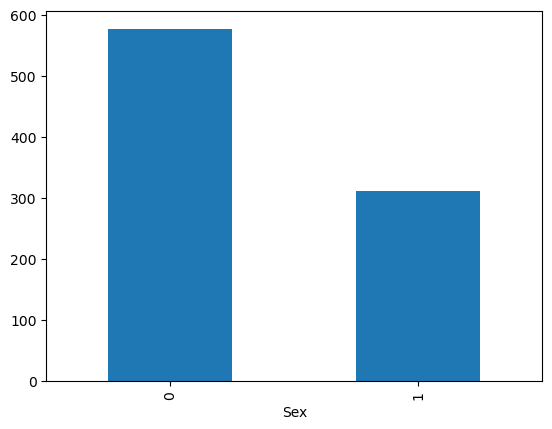

In [607]:
df['Sex'].value_counts().plot(kind='bar')

In [608]:
df['Embarked'].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

<Axes: xlabel='Embarked'>

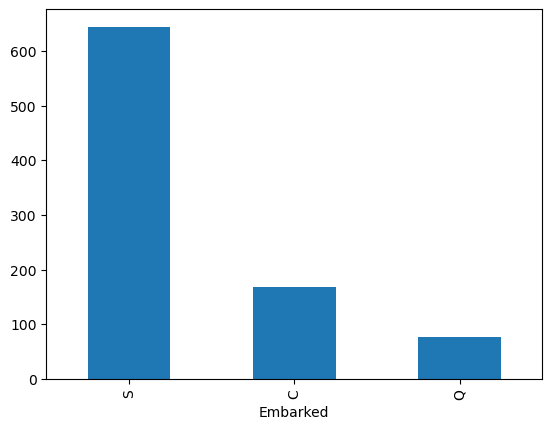

In [609]:
df['Embarked'].value_counts().plot(kind='bar')

In [610]:
df['Embarked'] = df['Embarked'].map({"S":2,"C":0,"Q":1})

In [611]:
df['Pclass'].value_counts()

Pclass
3    491
1    214
2    184
Name: count, dtype: int64

<Axes: xlabel='Fare', ylabel='Density'>

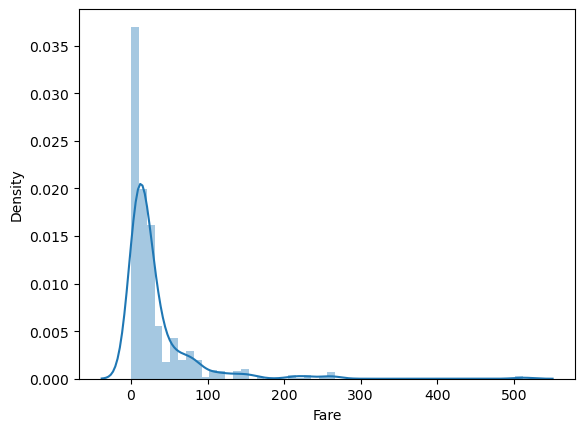

In [612]:
sns.distplot(df['Fare'])

<Axes: xlabel='Fare', ylabel='Density'>

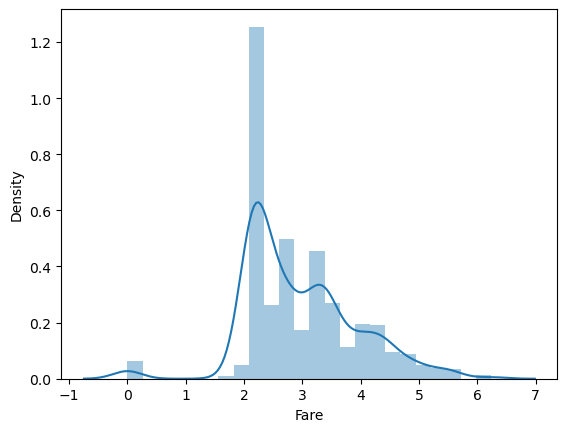

In [613]:
sns.distplot(np.log1p(df['Fare']))

In [614]:
# df['Fare'] = np.log1p(df['Fare'])

In [615]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,22,1,0,7.2500,2
1,1,1,1,38,1,0,71.2833,0
2,1,3,1,26,0,0,7.9250,2
3,1,1,1,35,1,0,53.1000,2
4,0,3,0,35,0,0,8.0500,2


In [616]:
df["FamilySize"] = df["SibSp"]+df["Parch"]+1
df = df.drop(columns = ['SibSp','Parch'])

In [617]:
df.head()

,Survived,Pclass,Sex,Age,Fare,Embarked,FamilySize
0,0,3,0,22,7.2500,2,2
1,1,1,1,38,71.2833,0,2
2,1,3,1,26,7.9250,2,1
3,1,1,1,35,53.1000,2,2
4,0,3,0,35,8.0500,2,1


In [618]:
X = df.drop(columns = ['Survived'])
y = df[['Survived']]

In [619]:
X.head()

,Pclass,Sex,Age,Fare,Embarked,FamilySize
0,3,0,22,7.2500,2,2
1,1,1,38,71.2833,0,2
2,3,1,26,7.9250,2,1
3,1,1,35,53.1000,2,2
4,3,0,35,8.0500,2,1


In [620]:
y.head()

,Survived
0,0
1,1
2,1
3,1
4,0


In [621]:
from sklearn.model_selection import train_test_split

In [622]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)

In [623]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

In [624]:
preprocessor = ColumnTransformer(
    transformers=[
        ('log', FunctionTransformer(np.log1p), ['Fare'])
    ],
    remainder='passthrough' 
)
pipe1 = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier())
])
pipe2 = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=100, 
        learning_rate=0.1, 
        max_depth=5, 
        random_state=42,
        use_label_encoder=False, 
        eval_metric='logloss'
    ))
])
pipe3 = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])
pipe4 = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        max_depth=5,            
        min_samples_split=10,  
        random_state=42
    ))
])

In [625]:
pipe1.fit(X_train,y_train)
pipe2.fit(X_train,y_train)
pipe3.fit(X_train,y_train)
pipe4.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('log',
                                                  FunctionTransformer(func=<ufunc 'log1p'>),
                                                  ['Fare'])])),
                ('classifier',
                 DecisionTreeClassifier(max_depth=5, min_samples_split=10,
                                        random_state=42))])

In [626]:
y_pred1 = pipe1.predict(X_test)
y_pred2 = pipe2.predict(X_test)
y_pred3 = pipe3.predict(X_test)
y_pred4 = pipe4.predict(X_test)

In [627]:
from sklearn.metrics import accuracy_score
ac1 = accuracy_score(y_test,y_pred1)*100
ac2 = accuracy_score(y_test,y_pred2)*100
ac3 = accuracy_score(y_test,y_pred3)*100
ac4 = accuracy_score(y_test,y_pred4)*100

In [628]:
ac1

79.21348314606742

In [629]:
ac2

81.46067415730337

In [630]:
ac3

79.21348314606742

In [631]:
ac4

80.33707865168539

In [633]:
import pickle
pickle.dump(df,open('df.pkl','wb'))
pickle.dump(pipe2,open('model.pkl','wb'))